# Low-Froude Kelvin Wake Simulation, Refined Version

This notebook is a cleaner and more reusable version of the original low-speed wake model.

## What it does
- models the **low-Froude-number** wake generated by a steadily moving disturbance
- keeps the theory at a level suitable for a group project
- makes the code reusable for **single plots**, **parameter scans**, and **diagnostic figures**

## Core equations
For deep-water gravity waves,

$$
\omega^2 = gk.
$$

In the frame moving with the disturbance, a stationary pattern satisfies

$$
\omega = Uk\cos\theta,
$$

so the allowed wavenumber is

$$
k(\theta)=\frac{g}{U^2\cos^2\theta}.
$$

We then superpose many angular wave contributions to reconstruct the free-surface elevation.



## Assumptions

This is a **simple linear model** intended for fast visualisation rather than full hydrodynamic realism.

We assume:
- incompressible, inviscid fluid
- irrotational flow
- deep-water gravity waves
- no surface tension
- a steady moving disturbance
- a Gaussian weighting in Fourier space to represent the finite size of the disturbance

This is enough to capture the main low-speed qualitative features:
- a Kelvin-like wake confined to the classical wedge
- stronger transverse waves at low Froude number
- visible change of pattern as $Fr$ is varied


In [1]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False



## Parameters and Computational Domain

Before constructing the wake pattern, we first define the main physical parameters and the two-dimensional spatial domain used for the simulation.

### Physical parameters

The parameter $g = 9.81\ \mathrm{m\,s^{-2}}$ is the gravitational acceleration. It is the key restoring force for deep-water gravity waves, and therefore enters directly into the dispersion relation

$$
\omega^2 = gk,
$$

where $\omega$ is the angular frequency and $k$ is the wavenumber. This dispersion relation shows that surface gravity waves are **dispersive**, meaning that waves of different wavelength travel at different speeds. This dispersive nature is the main reason why a steadily moving disturbance generates a structured wake pattern rather than a simple expanding ripple.

The parameter `length` represents the characteristic size of the moving disturbance. In a simplified model, this can be interpreted as an effective disturbance length scale, related to the size of the boat or the width of the pressure distribution acting on the water surface. This parameter is also used in the Froude number,

$$
Fr = \frac{U}{\sqrt{gL}},
$$

which compares the speed of the disturbance $U$ with the characteristic gravity-wave speed set by $g$ and the length scale $L$.

### Computational grid

The wake is calculated on a two-dimensional spatial grid. The coordinates are defined by

- $x \in [-12, 2]$
- $y \in [-6, 6]$

and then expanded into a full 2D mesh using `np.meshgrid(x, y)`.

This means that the free-surface elevation $\eta(x,y)$ will later be evaluated at every point in this rectangular region. In this notebook, the disturbance is placed at the origin and is taken to move in the positive $x$-direction. The wake therefore appears mainly in the downstream region, which in this coordinate convention corresponds to $x < 0$.

### Kelvin wake angle

A classical result from Kelvin wake theory is that, for a steadily moving disturbance on deep water, the far-field wake is confined within a wedge of half-angle

$$
\theta_K = \arcsin\left(\frac{1}{3}\right) \approx 19.47^\circ.
$$

This angle is called the **Kelvin half-angle**. Since the wake is symmetric about the direction of motion, the full wedge angle is approximately

$$
2\theta_K \approx 38.94^\circ.
$$

Physically, this angle defines the outer boundary of the classical Kelvin wake pattern. Although the detailed wave crests inside the wake depend on interference between many wave components, the overall visible wake remains confined within this wedge in the ideal deep-water theory.

In the simulation, the Kelvin angle is calculated as

```python
kelvin_angle = np.arcsin(1/3)


In [2]:

# Physical parameters
g = 9.81
length = 1.0

# Grid
x = np.linspace(-12, 2, 500)
y = np.linspace(-6, 6, 350)
X, Y = np.meshgrid(x, y)

kelvin_angle = np.arcsin(1/3)
print(f"Kelvin half-angle = {np.degrees(kelvin_angle):.2f} degrees")


Kelvin half-angle = 19.47 degrees


## Theory and construction of the low-Froude Kelvin-like wake model

In this section, we construct a simplified but physically motivated model for the wake generated by a steadily moving disturbance on deep water. The purpose of the model is to capture the main geometry of the wake in the low-Froude-number regime without solving the full fluid equations.

---

### 1. Physical picture

When a boat moves at constant speed across the water surface, it continuously disturbs the fluid. These disturbances generate surface gravity waves, which propagate away from the source. The wake pattern observed behind the boat is not produced by a single wave, but by the **interference of many wave components** travelling in different directions.

A key feature of water waves is that they are **dispersive**. This means that waves of different wavelength travel at different speeds. Because of this, the wake behind a moving disturbance is highly structured and forms the familiar Kelvin-like pattern rather than a simple circular ripple.

In this model, we treat the boat as a steadily moving disturbance located at the origin and moving in the positive $x$-direction. The wake is then reconstructed on a fixed spatial grid in the frame moving with the disturbance.

---

### 2. Deep-water gravity-wave dispersion relation

For deep-water gravity waves, the dispersion relation is

$$
\omega^2 = gk,
$$

where

- $\omega$ is the angular frequency,
- $k$ is the wavenumber,
- $g$ is the gravitational acceleration.

This relation tells us that the frequency is not proportional to the wavenumber, so the wave system is dispersive.

The corresponding phase velocity is

$$
c_p = \frac{\omega}{k} = \sqrt{\frac{g}{k}},
$$

and the group velocity is

$$
c_g = \frac{d\omega}{dk} = \frac{1}{2}\sqrt{\frac{g}{k}}.
$$

The distinction between phase velocity and group velocity is important in the full Kelvin wake theory, because wave crests and wave energy do not propagate in exactly the same way. In the present reduced model, we do not explicitly reconstruct the group-velocity geometry, but we do retain the key dispersion relation that governs the allowed stationary wave components.

---

### 3. Stationary-pattern condition in the moving frame

We are interested in the wake pattern seen in the frame moving with the boat. In this frame, the source is stationary, so the persistent wake must also appear stationary.

Consider a wave component propagating at an angle $\theta$ relative to the direction of motion. For the pattern to remain stationary in the moving frame, the temporal oscillation must be balanced by advection with the source. This gives the stationary condition

$$
\omega = U k \cos\theta,
$$

where

- $U$ is the disturbance speed,
- $\theta$ is the propagation angle measured from the direction of motion.

This condition can be understood as follows. The component of the boat speed along the propagation direction is $U\cos\theta$, and only wave components whose phase is locked to the moving source can contribute to the steady wake.

---

### 4. Derivation of the allowed wavenumber \(k(\theta)\)

We now combine the deep-water dispersion relation with the stationary condition.

Starting from

$$
\omega^2 = gk
$$

and

$$
\omega = U k \cos\theta,
$$

we substitute the second equation into the first:

$$
(U k \cos\theta)^2 = gk.
$$

Expanding the square gives

$$
U^2 k^2 \cos^2\theta = gk.
$$

Assuming $k \neq 0$, we divide both sides by $k$:

$$
U^2 k \cos^2\theta = g.
$$

Hence the allowed wavenumber is

$$
k(\theta) = \frac{g}{U^2 \cos^2\theta}.
$$

This is one of the central results of the model. It shows that, for each propagation direction $\theta$, only one wavenumber contributes to the stationary wake field.

---

### 5. Interpretation of \(k(\theta)\)

The expression

$$
k(\theta) = \frac{g}{U^2 \cos^2\theta}
$$

has several important consequences.

First, it shows that the wavenumber depends strongly on angle. As $|\theta|$ approaches $\pi/2$, we have $\cos\theta \to 0$, so $k(\theta)$ becomes very large. Physically, this means that directions nearly perpendicular to the direction of motion correspond to very short wavelengths in this stationary construction.

Second, it shows how the disturbance speed affects the wake spectrum. For larger $U$, the allowed wavenumbers become smaller on average, meaning that longer wavelengths contribute more strongly.

Third, the divergence near $\pm \pi/2$ is one reason why the numerical implementation excludes a small angular margin near these endpoints.

---

### 6. Angular superposition of plane-wave contributions

To reconstruct the free-surface disturbance, we treat the wake as a superposition of many angular wave contributions. For each direction $\theta$, we associate a plane-wave phase

$$
\phi(\theta; x,y) = k(\theta)\big(x\cos\theta + y\sin\theta\big).
$$

Here,

$$
x\cos\theta + y\sin\theta
$$

is simply the projection of the position vector onto the propagation direction.

The contribution from one angular component is then written as

$$
\eta_\theta(x,y) \propto A(\theta)\cos\phi(\theta; x,y),
$$

where $A(\theta)$ is the amplitude weighting.

Summing over all directions gives the total free-surface field:

$$
\eta(x,y)
=
\int_{-\pi/2}^{\pi/2}
A(\theta)
\cos\!\Big(k(\theta)\,[x\cos\theta + y\sin\theta]\Big)\,
d\theta.
$$

This integral is evaluated numerically in the code by discretising the angle interval into many small steps.

---

### 7. Why a finite-size disturbance is needed

If the disturbance were treated as an ideal point source, all wavelengths could in principle contribute equally. However, a real boat has a finite size, and therefore it does not excite all wavelengths with the same efficiency.

A finite disturbance acts like a spectral filter. Very short wavelengths tend to be suppressed because the pressure distribution is spread out in space rather than concentrated at a point. To represent this effect, we introduce a Gaussian spectral weighting.

---

### 8. Gaussian spectral weighting

We choose

$$
A(k) = \exp\!\left[-\frac{(kL)^2}{C}\right],
$$

where

- $L$ is the characteristic disturbance size,
- $C$ is a numerical constant controlling how sharply the spectrum is cut off.

Since $k$ depends on $\theta$, this also defines an angular weighting:

$$
A(\theta) = \exp\!\left[-\frac{(k(\theta)L)^2}{C}\right].
$$

This weighting has a clear physical interpretation:

- when $kL$ is small, the exponential is close to 1, so those modes contribute strongly,
- when $kL$ is large, the exponential decays rapidly, so high-wavenumber modes are suppressed.

Thus, the finite-size disturbance introduces a physically motivated spectral cutoff and helps produce a smoother and more realistic wake pattern.

---

### 9. Numerical approximation of the angular integral

In the code, the continuous angular integral is replaced by a discrete sum. If the angles are sampled as

$$
\theta_1, \theta_2, \dots, \theta_N,
$$

with spacing

$$
\Delta\theta,
$$

then the wake field is approximated by

$$
\eta(x,y)
\approx
\sum_{j=1}^{N}
A(\theta_j)
\cos\!\Big(k(\theta_j)\,[x\cos\theta_j + y\sin\theta_j]\Big)
\,\Delta\theta.
$$

This is exactly what the numerical routine computes. The code uses a large number of angles to obtain a smooth approximation, and processes them in batches for computational efficiency.

---

### 10. Connection with the Froude number

The dimensionless control parameter for the problem is the Froude number,

$$
Fr = \frac{U}{\sqrt{gL}}.
$$

This compares the boat speed $U$ with the characteristic gravity-wave speed associated with the length scale $L$.

In the code, the user specifies the Froude number, and the disturbance speed is reconstructed as

$$
U = Fr\sqrt{gL}.
$$

This is convenient because the regime of the wake is more naturally described by $Fr$ than by dimensional speed alone.

In the low-Froude-number regime, the wake retains a Kelvin-like structure, and the simulation is used to explore how the visible pattern develops as the speed varies within this regime.

---

### 11. Kelvin angle and the classical wake wedge

A classical result in deep-water wake theory is that the far-field Kelvin wake is confined to a wedge with half-angle

$$
\theta_K = \arcsin\left(\frac{1}{3}\right) \approx 19.47^\circ.
$$

This angle is not imposed directly in the numerical summation, but it is used as a theoretical reference when plotting the wake field. In practice, it helps to compare the simulated pattern with the expected classical Kelvin wedge.

---

### 12. Assumptions and limitations of the model

This model is intentionally simplified. It is designed to capture the main geometry of the wake while remaining accessible for a group project.

The main assumptions are:

1. **Deep-water approximation**  
   The dispersion relation $\omega^2 = gk$ assumes deep water.

2. **Linear wave theory**  
   Nonlinear wave effects are neglected.

3. **Steady moving disturbance**  
   The source moves at constant speed in a straight line.

4. **Reduced spectral model**  
   The wake is reconstructed from angular plane-wave superposition rather than from a full hydrodynamic solution.

5. **Simplified finite-size weighting**  
   The Gaussian cutoff is physically motivated but not derived from a detailed boat geometry.

Because of these assumptions, the model should be viewed as a **Kelvin-like reduced wake model**, not as a full CFD simulation. Its strength is that it retains the essential wave-dispersion physics while remaining simple enough to interpret and modify.

---

### 13. Final model summary

The model used in the code can be summarised by the following steps:

1. Choose a Froude number $Fr$ and compute the speed
   $$
   U = Fr\sqrt{gL}.
   $$

2. For each propagation angle $\theta$, determine the allowed stationary wavenumber
   $$
   k(\theta) = \frac{g}{U^2\cos^2\theta}.
   $$

3. Apply a finite-size spectral weighting
   $$
   A(\theta) = \exp\!\left[-\frac{(k(\theta)L)^2}{C}\right].
   $$

4. Reconstruct the free-surface elevation by angular superposition
   $$
   \eta(x,y)
   =
   \int
   A(\theta)\,
   \cos\!\Big(k(\theta)\,[x\cos\theta + y\sin\theta]\Big)\,
   d\theta.
   $$

This gives a computationally efficient and physically interpretable model for studying the low-Froude Kelvin-like wake.


In [3]:

def wake_field(
    froude_number,
    g=9.81,
    length=1.0,
    X=None,
    Y=None,
    ntheta=1000,
    theta_margin=0.02,
    amplitude_const=40.0,
    batch_size=200,
):
    """Compute a Kelvin-like wake field using chunked angular superposition."""
    if X is None or Y is None:
        raise ValueError("X and Y must be provided.")

    speed = froude_number * np.sqrt(g * length)

    theta = np.linspace(-np.pi/2 + theta_margin, np.pi/2 - theta_margin, ntheta)
    dtheta = theta[1] - theta[0]

    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)

    # Allowed wavenumber from deep-water dispersion and stationary condition
    k = g / (speed**2 * cos_theta**2)

    # Gaussian spectral weighting
    A = np.exp(-(k * length)**2 / amplitude_const)

    # Flatten grid for faster batched matrix operations
    XY = np.stack([X.ravel(), Y.ravel()], axis=1)
    directions = np.stack([cos_theta, sin_theta], axis=1)

    eta_flat = np.zeros(X.size, dtype=float)

    for start in range(0, len(theta), batch_size):
        stop = min(start + batch_size, len(theta))
        sl = slice(start, stop)

        projection = directions[sl] @ XY.T
        phase = k[sl, None] * projection
        eta_flat += (A[sl, None] * np.cos(phase)).sum(axis=0)

    eta = eta_flat.reshape(X.shape) * dtheta
    return eta, speed, theta, k, A


## Single low-Froude example

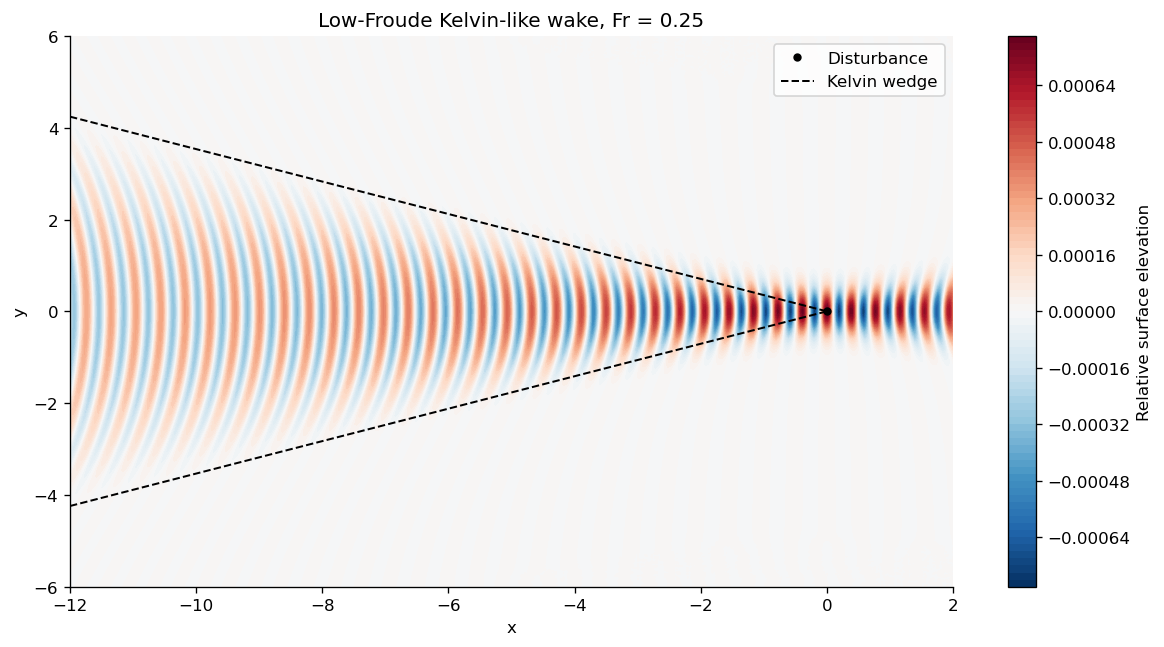

Speed used: U = 0.783 m/s


In [4]:

Fr_example = 0.25
eta, speed, theta, k, A = wake_field(
    froude_number=Fr_example,
    g=g,
    length=length,
    X=X,
    Y=Y,
    ntheta=1000,
    amplitude_const=40.0,
)

plt.figure(figsize=(10, 5.5))
cf = plt.contourf(X, Y, eta, levels=100, cmap="RdBu_r")
plt.colorbar(cf, label="Relative surface elevation")

plt.plot(0, 0, "ko", ms=4, label="Disturbance")

x_line = np.linspace(x.min(), 0, 300)
y_upper = np.tan(kelvin_angle) * (-x_line)
y_lower = -np.tan(kelvin_angle) * (-x_line)
plt.plot(x_line, y_upper, "k--", lw=1.2, label="Kelvin wedge")
plt.plot(x_line, y_lower, "k--", lw=1.2)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Low-Froude Kelvin-like wake, Fr = {Fr_example:.2f}")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"Speed used: U = {speed:.3f} m/s")


## Example wake pattern at low Froude number

The figure below shows the simulated free-surface field for a representative low-Froude-number case, here chosen as $Fr = 0.25$.

The black dot at the origin marks the location of the moving disturbance. In this coordinate convention, the disturbance moves in the positive $x$-direction, so the wake is mainly shown in the downstream region $x < 0$.

The coloured field represents the **relative surface elevation** $\eta(x,y)$, that is, the displacement of the water surface relative to the undisturbed level. Positive values correspond to wave crests and negative values correspond to wave troughs. The alternating red and blue bands therefore show the spatial structure of the wake.

The dashed black lines indicate the **classical Kelvin wedge**, whose half-angle is

$$
\theta_K = \arcsin\left(\frac{1}{3}\right)\approx 19.47^\circ.
$$

This wedge provides a theoretical reference for the expected far-field wake boundary in deep water. In the present simulation, the main wake structure lies largely inside this wedge, consistent with the Kelvin-like behaviour expected in the low-Froude-number regime.

The speed $U$ printed below the figure is the dimensional disturbance speed corresponding to the chosen Froude number, obtained from

$$
U = Fr\sqrt{gL}.
$$

For the parameters used here, $Fr=0.25$, $g=9.81\ \mathrm{m\,s^{-2}}$, and $L=1.0$, giving

$$
U \approx 0.783\ \mathrm{m\,s^{-1}}.
$$


## Low-Froude parameter scan

This is the most useful figure for your part of the project.
It shows how the wake changes through the low-speed regime.


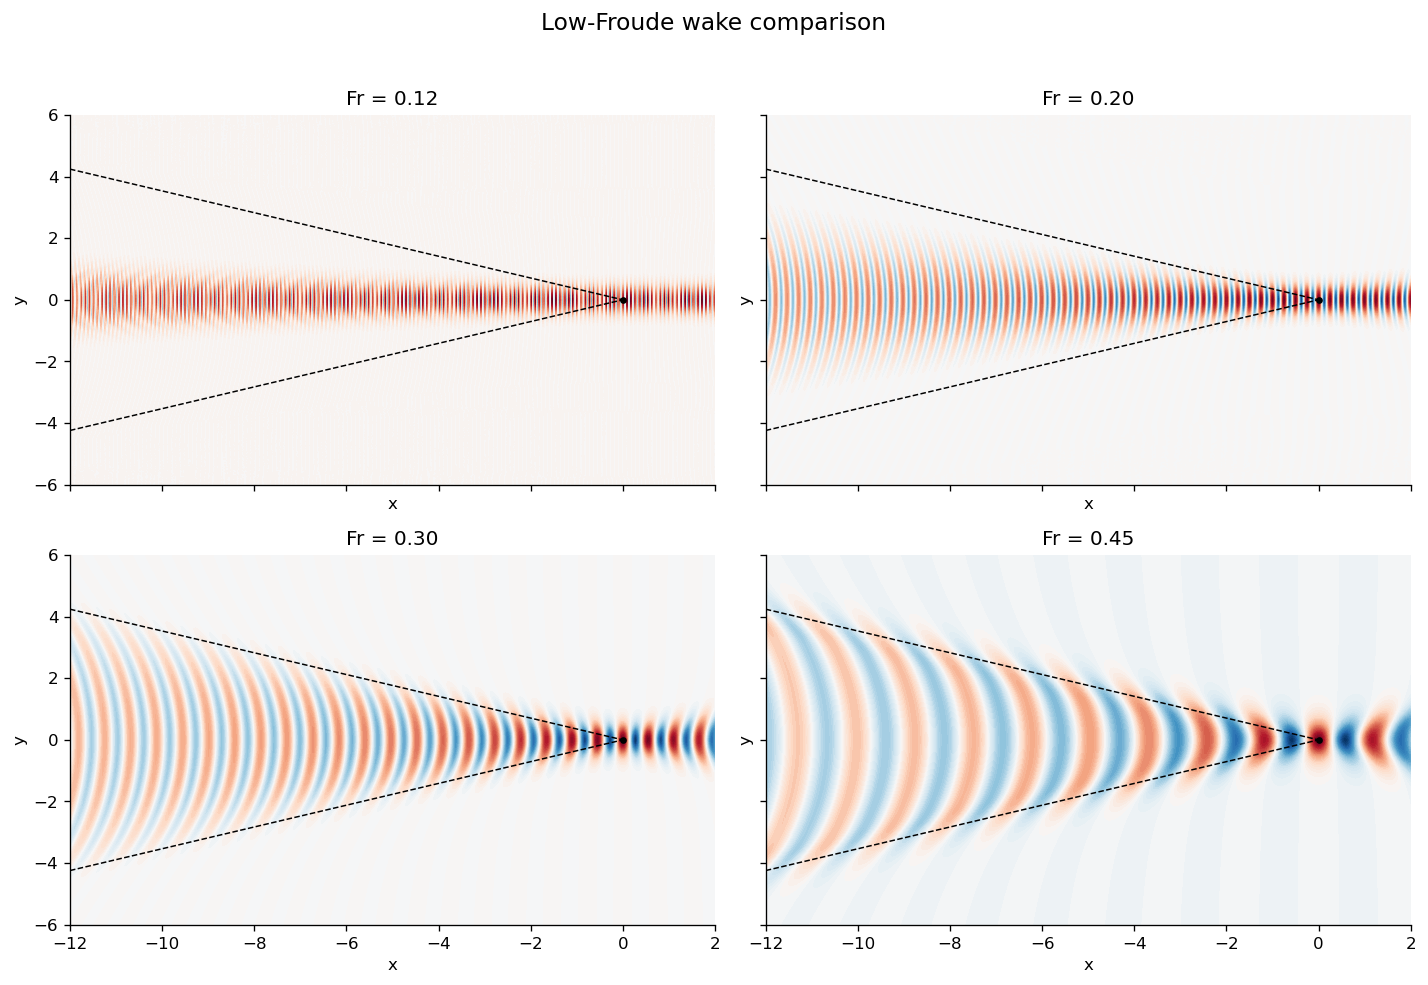

In [5]:

low_fr_values = [0.12, 0.20, 0.30, 0.45]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for ax, Fr in zip(axes.flat, low_fr_values):
    eta, speed, theta, k, A = wake_field(
        froude_number=Fr,
        g=g,
        length=length,
        X=X,
        Y=Y,
        ntheta=800,
        amplitude_const=40.0,
    )

    cf = ax.contourf(X, Y, eta, levels=80, cmap="RdBu_r")
    ax.plot(0, 0, "ko", ms=3)

    x_line = np.linspace(x.min(), 0, 300)
    y_upper = np.tan(kelvin_angle) * (-x_line)
    y_lower = -np.tan(kelvin_angle) * (-x_line)
    ax.plot(x_line, y_upper, "k--", lw=0.9)
    ax.plot(x_line, y_lower, "k--", lw=0.9)

    ax.set_title(f"Fr = {Fr:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.suptitle("Low-Froude wake comparison", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


## Result analysis: low-Froude parameter scan

The four-panel figure shows how the simulated Kelvin-like wake changes as the Froude number increases within the low-speed regime. In all cases, the disturbance is located at the origin, and the dashed lines mark the classical Kelvin wedge with half-angle

$$
\theta_K = \arcsin\left(\frac{1}{3}\right)\approx 19.47^\circ.
$$

The coloured field represents the relative surface elevation, with alternating positive and negative values corresponding to wave crests and troughs.

Several clear trends can be observed.

### 1. Very low Froude number: narrow and weakly spread wake

For $Fr = 0.12$, the wake remains highly concentrated near the centreline $y=0$. The wave pattern is dominated by nearly transverse oscillations, with very limited lateral spreading. Although the Kelvin wedge is shown for reference, the visible wake occupies only a small portion of that wedge. This indicates that at very low speed, the disturbance does not efficiently generate a broad range of outward-propagating wave components.

### 2. Intermediate low-Froude regime: increasing lateral spreading

For $Fr = 0.20$ and $Fr = 0.30$, the wake becomes much more visibly developed. The oscillatory structure extends further in the transverse direction, and the overall pattern more clearly fills the interior of the Kelvin wedge. In this regime, the wake begins to resemble the familiar Kelvin-like form, with a broader and more structured interference pattern behind the disturbance.

This behaviour is consistent with the dependence of the allowed wavenumber on speed,

$$
k(\theta)=\frac{g}{U^2\cos^2\theta}.
$$

As the disturbance speed $U$ increases, the characteristic wavenumbers decrease, and longer-wavelength contributions become more important. This allows the wake structure to spread more effectively across the wedge.

### 3. Upper end of the low-Froude scan: broader and more pronounced wake

For $Fr = 0.45$, the wake spreads over a much larger fraction of the Kelvin wedge and the wavefronts become more widely spaced. The pattern is visually stronger and more extended than in the lower-$Fr$ cases. At this stage, the wake is no longer confined to a thin band around the centreline, but occupies a substantial part of the available wedge region.

This trend suggests that increasing the Froude number within the low-speed regime enhances the visibility of the Kelvin-like pattern and makes the angular structure of the wake more pronounced.

### 4. Comparison with the classical Kelvin wedge

Across all four panels, the dashed Kelvin wedge provides a useful theoretical reference. The simulated wake remains largely inside this wedge, which is consistent with the classical deep-water Kelvin picture. However, the extent to which the interior of the wedge is visibly populated depends strongly on the Froude number.

At the smallest $Fr$, the visible wake occupies only a narrow band near the centreline. As $Fr$ increases, the wake progressively fills more of the wedge. This shows that the Kelvin angle is a geometric boundary of the classical theory, but the actual visible wake pattern inside that boundary depends on the spectral content of the disturbance and on the Froude number.

### 5. Physical interpretation

The main physical conclusion from this parameter scan is that, within the low-Froude regime, increasing $Fr$ leads to a more spatially extended and more clearly recognisable Kelvin-like wake. At very small $Fr$, the wake is concentrated close to the centreline and dominated by narrow oscillatory structure. At larger low-speed $Fr$, the wake broadens and more fully develops the characteristic wedge-shaped interference pattern.

This makes the low-Froude parameter scan particularly useful for identifying the onset of a visibly developed Kelvin-like wake and for understanding how the wake geometry evolves before entering higher-Froude-number behaviour.

As the Froude number increases from 0.12 to 0.45, the simulated wake becomes progressively broader and more clearly developed within the Kelvin wedge. At very low $Fr$, the wake is concentrated near the centreline and shows limited lateral spreading. As $Fr$ increases, the oscillatory pattern extends further across the wedge, producing a more recognisable Kelvin-like wake structure. This suggests that, even within the low-speed regime, the visible wake geometry depends strongly on the Froude number.

## Diagnostics: allowed wavenumbers and Gaussian weighting

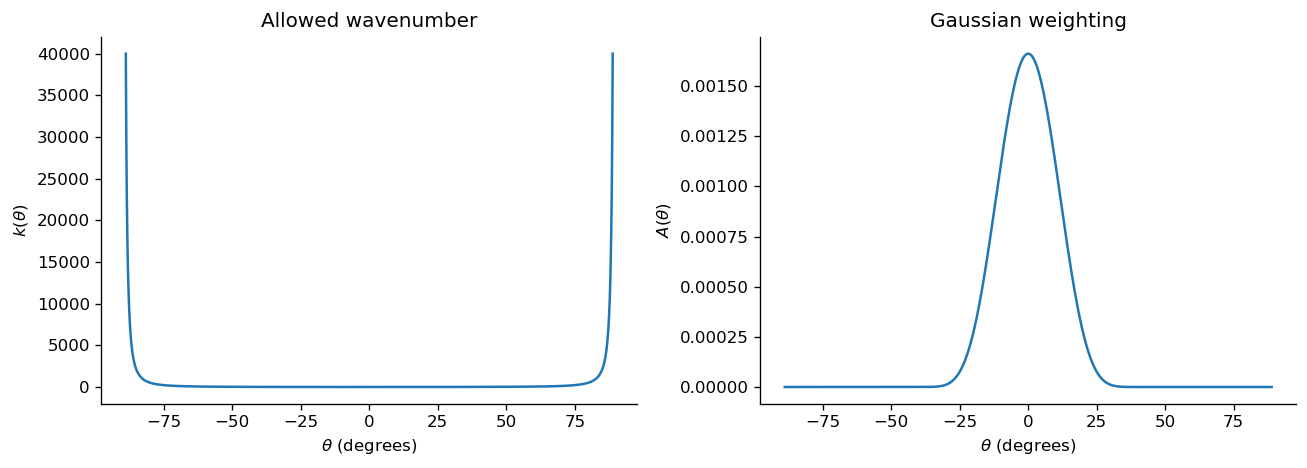

In [6]:

Fr_diagnostic = 0.25
eta, speed, theta, k, A = wake_field(
    froude_number=Fr_diagnostic,
    g=g,
    length=length,
    X=X,
    Y=Y,
    ntheta=1000,
    amplitude_const=40.0,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(np.degrees(theta), k)
axes[0].set_xlabel(r"$\theta$ (degrees)")
axes[0].set_ylabel(r"$k(\theta)$")
axes[0].set_title("Allowed wavenumber")

axes[1].plot(np.degrees(theta), A)
axes[1].set_xlabel(r"$\theta$ (degrees)")
axes[1].set_ylabel(r"$A(\theta)$")
axes[1].set_title("Gaussian weighting")

fig.tight_layout()
plt.show()


## Diagnostics: allowed wavenumbers and Gaussian weighting

The two diagnostic plots are used to examine the internal structure of the reduced wake model for a representative case, here chosen as $Fr = 0.25$.

The left panel shows the allowed wavenumber

$$
k(\theta)=\frac{g}{U^2\cos^2\theta},
$$

which is obtained by combining the deep-water gravity-wave dispersion relation with the stationary-pattern condition in the moving frame. This plot shows that the allowed wavenumber is smallest near $\theta=0$ and increases sharply as $|\theta|$ approaches $90^\circ$. Physically, this means that wave components propagating close to the direction of motion correspond to longer wavelengths, while near-transverse directions correspond to very short wavelengths.

The right panel shows the Gaussian spectral weighting

$$
A(\theta)=\exp\!\left[-\frac{(k(\theta)L)^2}{C}\right].
$$

This weighting suppresses the large-$k$ contributions associated with angles near $\pm 90^\circ$. As a result, although the stationary construction formally allows very large wavenumbers at large angles, these modes contribute very little to the final wake field. The dominant contribution instead comes from a narrower range of angles around $\theta=0$.

Together, these two plots explain how the wake is constructed. The left panel determines which wavenumbers are allowed by the theory, while the right panel determines which of those allowed modes are strongly excited by a finite-size disturbance. The final Kelvin-like wake is obtained by superposing these weighted angular contributions.

## Centreline cut

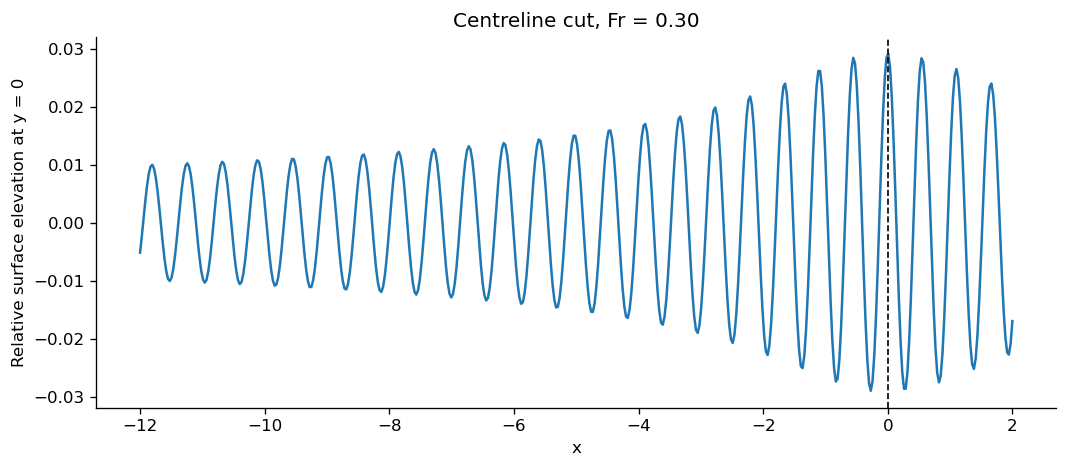

In [7]:

Fr_cut = 0.30
eta, speed, theta, k, A = wake_field(
    froude_number=Fr_cut,
    g=g,
    length=length,
    X=X,
    Y=Y,
    ntheta=900,
    amplitude_const=40.0,
)

iy0 = np.argmin(np.abs(y))
plt.figure(figsize=(9, 4))
plt.plot(x, eta[iy0, :])
plt.axvline(0, color="k", ls="--", lw=1)
plt.xlabel("x")
plt.ylabel("Relative surface elevation at y = 0")
plt.title(f"Centreline cut, Fr = {Fr_cut:.2f}")
plt.tight_layout()
plt.show()


## Result analysis: centreline cut

To obtain a more quantitative view of the wake structure, we extract a centreline cut of the free-surface elevation at $y=0$. This corresponds to plotting

$$
\eta(x,0),
$$

that is, the relative surface elevation along the symmetry axis of the wake.

The resulting curve shows an oscillatory structure with alternating positive and negative values, corresponding to successive wave crests and troughs along the wake centreline. The dashed vertical line at $x=0$ marks the location of the moving disturbance.

Compared with the two-dimensional contour plot, the centreline cut provides a simpler one-dimensional view of the wake. It makes it easier to identify the spacing of the oscillations, the variation of the amplitude along the wake axis, and the general downstream evolution of the wave pattern.

For the present case, $Fr=0.30$, the oscillations are strongest near the disturbance and gradually weaken further downstream. This is consistent with the idea that the wake structure is most intense close to the source and becomes more diffuse as the pattern extends into the downstream region.

The centreline cut is therefore a useful diagnostic tool for comparing wake structure at different Froude numbers and for quantifying features such as wavelength, oscillation amplitude, and downstream decay.

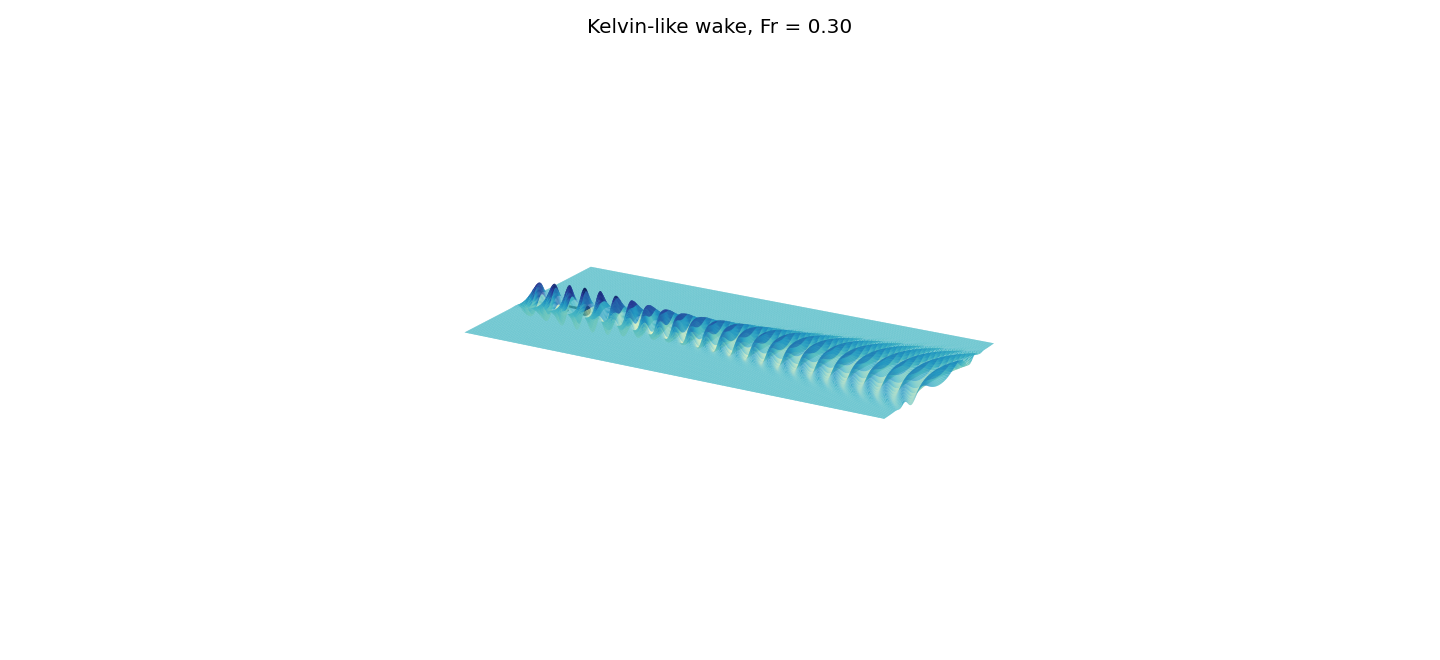

In [11]:
%matplotlib widget
# 先开交互式后端（如果你想拖动）
# %matplotlib notebook

from mpl_toolkits.mplot3d import Axes3D

Fr_3d = 0.30
eta, speed, theta, k, A = wake_field(
    froude_number=Fr_3d,
    g=g,
    length=length,
    X=X,
    Y=Y,
    ntheta=900,
    amplitude_const=40.0,
)

# 为了让图像更像参考图，把显示方向翻转：
# 原来 wake 主要在 x<0，现在显示成向右展开
X_plot = -X
Y_plot = Y

# 适度放大 z 方向，但不要太夸张
zscale = 8
Z_plot = eta * zscale

fig = plt.figure(figsize=(12, 5.5))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X_plot, Y_plot, Z_plot,
    cmap="YlGnBu",
    linewidth=0,
    antialiased=True,
    shade=True,
    rcount=180,
    ccount=180
)

# 标出船/扰动源位置
ax.scatter([0], [0], [0], color="k", s=30)

# 可选：加一个很短的小箭头表示前进方向
ax.quiver(
    0, 0, 0,
    -0.8, 0, 0,
    color="k",
    linewidth=1.5,
    arrow_length_ratio=0.25
)

# 视角调成更接近参考图
ax.view_init(elev=20, azim=-60)

# 压扁 z 轴比例，让表面更平滑，不要像山峰
ax.set_box_aspect((14, 7, 1.4))

# 去掉坐标轴、刻度、网格、背景面
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.grid(False)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor("white")

# 去掉 3D 轴线（不同版本 matplotlib 兼容性略有区别）
try:
    ax.xaxis.line.set_color((1, 1, 1, 0))
    ax.yaxis.line.set_color((1, 1, 1, 0))
    ax.zaxis.line.set_color((1, 1, 1, 0))
except:
    pass

ax.set_title(f"Kelvin-like wake, Fr = {Fr_3d:.2f}", pad=10)

plt.tight_layout()
plt.show()

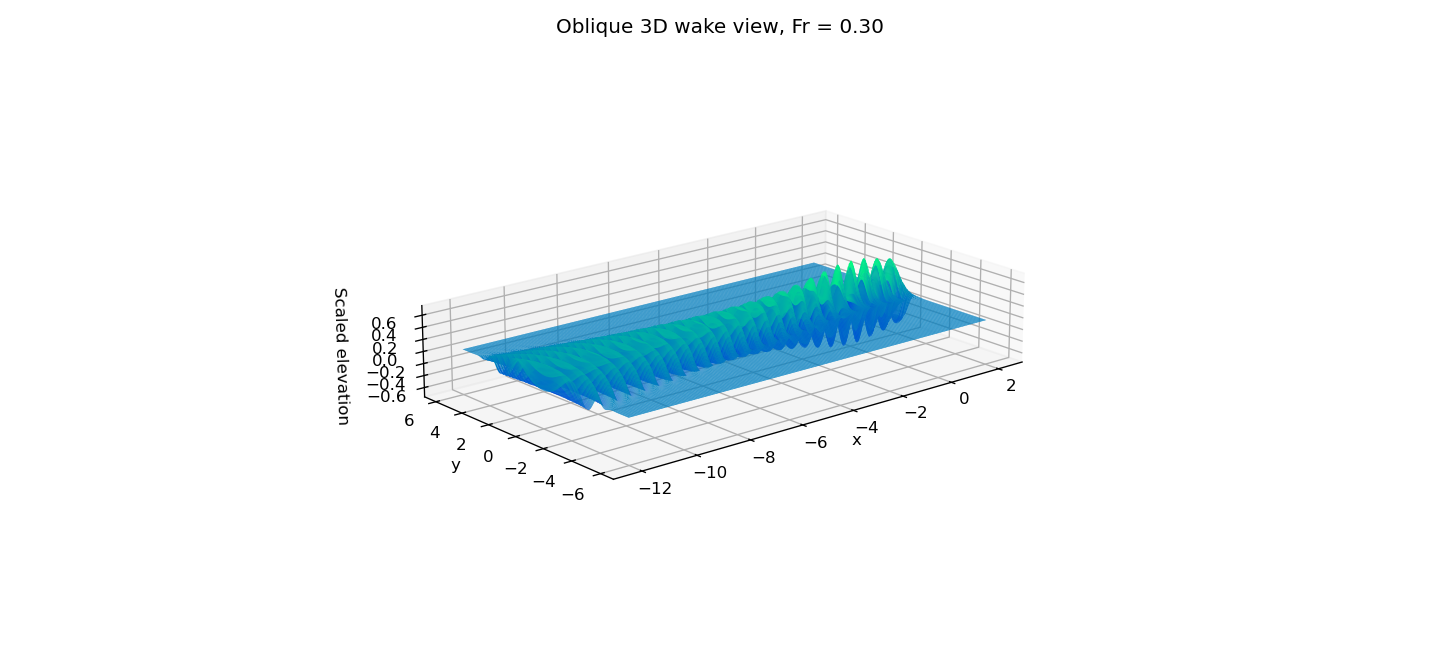

In [12]:
from mpl_toolkits.mplot3d import Axes3D

Fr_3d = 0.30
eta, speed, theta, k, A = wake_field(
    froude_number=Fr_3d,
    g=g,
    length=length,
    X=X,
    Y=Y,
    ntheta=900,
    amplitude_const=40.0,
)

zscale = 25
Z = eta * zscale

fig = plt.figure(figsize=(12, 5.5))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X, Y, Z,
    cmap="winter",
    linewidth=0,
    antialiased=True,
    shade=True,
    rcount=240,
    ccount=240
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Scaled elevation")
ax.set_title(f"Oblique 3D wake view, Fr = {Fr_3d:.2f}")

ax.view_init(elev=18, azim=-130)
ax.set_box_aspect((14, 8, 2.5))

plt.tight_layout()
plt.show()

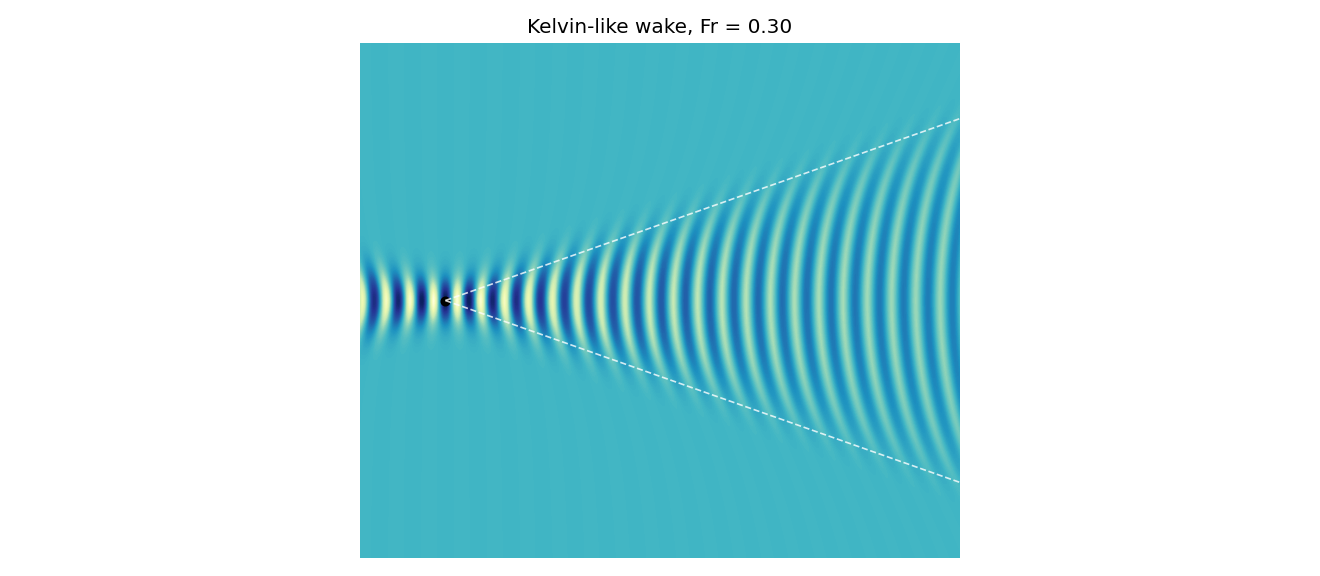

In [13]:
Fr_view = 0.30
eta, speed, theta, k, A = wake_field(
    froude_number=Fr_view,
    g=g,
    length=length,
    X=X,
    Y=Y,
    ntheta=900,
    amplitude_const=40.0,
)

# 显示时翻转 x，让船在左、wake 向右
X_show = -X
Y_show = Y

fig, ax = plt.subplots(figsize=(11, 4.8))

cf = ax.contourf(
    X_show, Y_show, eta,
    levels=160,
    cmap="YlGnBu"
)

# 船的位置
ax.plot(0, 0, "k.", ms=10)

# Kelvin wedge 也翻转成向右展开
x_line = np.linspace(0, -x.min(), 300)
y_upper = np.tan(kelvin_angle) * x_line
y_lower = -np.tan(kelvin_angle) * x_line
ax.plot(x_line, y_upper, color="w", ls="--", lw=1.0, alpha=0.8)
ax.plot(x_line, y_lower, color="w", ls="--", lw=1.0, alpha=0.8)

ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(f"Kelvin-like wake, Fr = {Fr_view:.2f}")
plt.tight_layout()
plt.show()

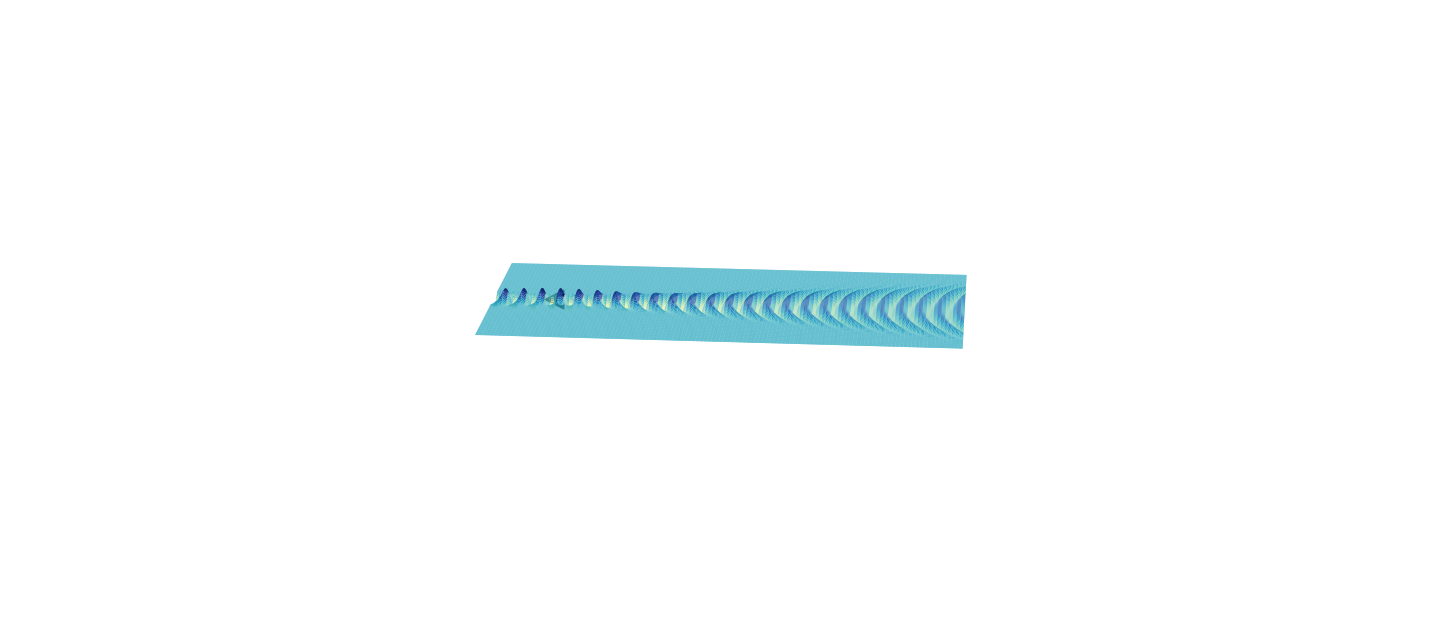

In [15]:
# %matplotlib notebook

from mpl_toolkits.mplot3d import Axes3D

Fr_3d = 0.30
eta, speed, theta, k, A = wake_field(
    froude_number=Fr_3d,
    g=g,
    length=length,
    X=X,
    Y=Y,
    ntheta=900,
    amplitude_const=40.0,
)

# 翻转显示方向，让船在左边，wake 向右展开
X_plot = -X
Y_plot = Y

# 再压低一点起伏
zscale = 5
Z_plot = eta * zscale

fig = plt.figure(figsize=(12, 5.2))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X_plot, Y_plot, Z_plot,
    cmap="YlGnBu",
    linewidth=0,
    antialiased=True,
    shade=True,
    rcount=160,
    ccount=160
)
# --- boat marker ---
boat_x = 0.0
boat_y = 0.0
boat_z = 0.0

# 船身：短黑线
ax.plot(
    [boat_x - 0.18, boat_x + 0.05],
    [boat_y, boat_y],
    [boat_z, boat_z],
    color="k",
    lw=3,
    solid_capstyle="round"
)

# 船头：黑色三角
ax.scatter(
    [boat_x - 0.20],
    [boat_y],
    [boat_z],
    color="k",
    s=120,
    marker="<"
)
# 船的位置
ax.scatter([0], [0], [0], color="white", s=20)

# 视角微调
ax.view_init(elev=18, azim=-85)

# 更扁一点，更像液面
ax.set_box_aspect((14, 7, 0.7))

# 去掉一切轴元素
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.grid(False)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor("white")

try:
    ax.xaxis.line.set_color((1, 1, 1, 0))
    ax.yaxis.line.set_color((1, 1, 1, 0))
    ax.zaxis.line.set_color((1, 1, 1, 0))
except:
    pass

plt.tight_layout()
plt.show()

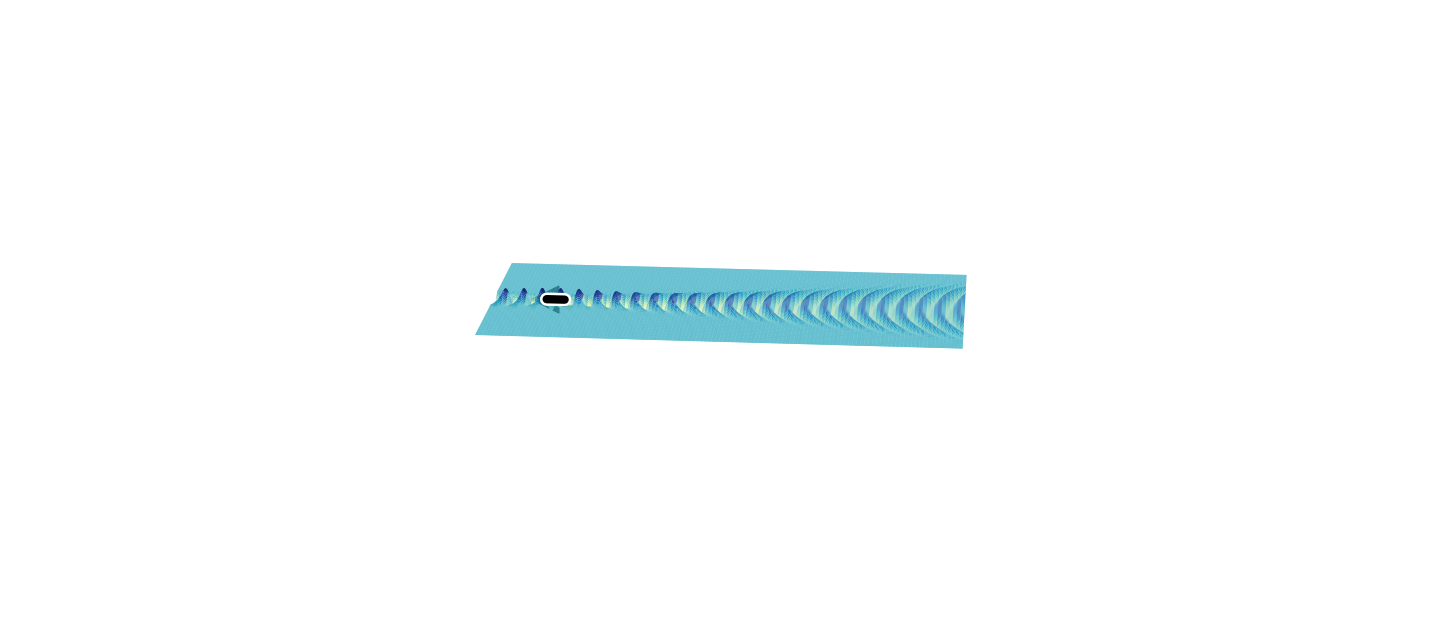

In [17]:
# %matplotlib notebook

from mpl_toolkits.mplot3d import Axes3D

Fr_3d = 0.30
eta, speed, theta, k, A = wake_field(
    froude_number=Fr_3d,
    g=g,
    length=length,
    X=X,
    Y=Y,
    ntheta=900,
    amplitude_const=40.0,
)

# 翻转显示方向，让船在左边，wake 向右展开
X_plot = -X
Y_plot = Y

# 压低起伏，保持更像液面
zscale = 5
Z_plot = eta * zscale

fig = plt.figure(figsize=(12, 5.2))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X_plot, Y_plot, Z_plot,
    cmap="YlGnBu",
    linewidth=0,
    antialiased=True,
    shade=True,
    rcount=160,
    ccount=160
)

# =========================
# =========================
# 更明显的小船标记（白边黑心）
# =========================
boat_x = 0.0
boat_y = 0.0
boat_z = 0.0

# 船身白色底边
ax.plot(
    [boat_x - 0.42, boat_x + 0.12],
    [boat_y, boat_y],
    [boat_z, boat_z],
    color="white",
    lw=8,
    solid_capstyle="round",
    zorder=20
)

# 船身黑色主体
ax.plot(
    [boat_x - 0.42, boat_x + 0.12],
    [boat_y, boat_y],
    [boat_z, boat_z],
    color="k",
    lw=5,
    solid_capstyle="round",
    zorder=21
)

# 船头白色描边三角
ax.scatter(
    [boat_x - 0.46],
    [boat_y],
    [boat_z],
    color="white",
    s=420,
    marker="<",
    zorder=22
)

# 船头黑色主体三角
ax.scatter(
    [boat_x - 0.46],
    [boat_y],
    [boat_z],
    color="k",
    s=250,
    marker="<",
    zorder=23
)

# 船尾白色描边圆点
ax.scatter(
    [boat_x + 0.10],
    [boat_y],
    [boat_z],
    color="white",
    s=90,
    marker="o",
    zorder=22
)

# 船尾黑色主体圆点
ax.scatter(
    [boat_x + 0.10],
    [boat_y],
    [boat_z],
    color="k",
    s=45,
    marker="o",
    zorder=23
)
# =========================
# 视角与外观
# =========================
ax.view_init(elev=18, azim=-85)
ax.set_box_aspect((14, 7, 0.7))

# 去掉坐标轴、刻度、网格
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.grid(False)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor("white")

try:
    ax.xaxis.line.set_color((1, 1, 1, 0))
    ax.yaxis.line.set_color((1, 1, 1, 0))
    ax.zaxis.line.set_color((1, 1, 1, 0))
except:
    pass

plt.tight_layout()
plt.show()

## Limitations of the present model

Although the present simulation captures the main geometry of a low-Froude Kelvin-like wake, it remains a reduced and idealised model. Several important physical effects are not included.

First, the wake is constructed by angular superposition of linear wave components rather than by solving the full hydrodynamic equations. As a result, the model captures the large-scale interference structure of the wake, but not the detailed near-field flow around a realistic hull.

Second, the moving disturbance is represented through a simplified finite-size spectral weighting rather than a true boat geometry. This means that the model is better suited to qualitative wake patterns than to quantitative prediction for a specific vessel.

Third, dissipative effects such as viscosity, turbulence, and wave damping are neglected. The simulated far-field wake may therefore remain more coherent than a real wake in water.

Fourth, the model assumes deep-water gravity waves and does not include finite-depth effects. In shallow or intermediate-depth water, the dispersion relation would be modified and the wake structure could change significantly.

Fifth, the model neglects surface tension, background currents, wind forcing, and boundary reflections. It therefore represents an ideal open-water situation rather than a realistic natural environment.

Finally, the present implementation is most reliable for exploring the low-Froude Kelvin-like regime. A more complete treatment of the high-Froude transition and apparent Mach-like narrowing would require additional analysis of finite-size source effects and wake-angle extraction.